### Logistic Regression Modeling

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import fastparquet
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import joblib

In [2]:
# load data and print shape
X_train = pd.read_parquet('X_train.parquet')
y_train = pd.read_parquet('Y_train.parquet')
X_val = pd.read_parquet('X_val.parquet')
y_val = pd.read_parquet('Y_val.parquet')
X_test = pd.read_parquet('X_test.parquet')
y_test = pd.read_parquet('Y_test.parquet')

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_val:', X_val.shape)
print('y_val:', y_val.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)


X_train: (3040, 146)
y_train: (3040, 4)
X_val: (1014, 146)
y_val: (1014, 4)
X_test: (1014, 146)
y_test: (1014, 4)


### Quick EDA, binary classification, upsampling

In [3]:
# check general features of X_train
X_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 146 columns):
 #    Column                                                            Non-Null Count  Dtype  
---   ------                                                            --------------  -----  
 0    max_education_9-11th grade (includes 12th grade with no diploma)  3040 non-null   float64
 1    max_education_College graduate or above                           3040 non-null   float64
 2    max_education_High school graduate/GED or equivalent              3040 non-null   float64
 3    max_education_Missing                                             3040 non-null   float64
 4    max_education_Some college or AA degree                           3040 non-null   float64
 5    max_education_less than 9th grade                                 3040 non-null   float64
 6    max_education_nan                                                 3040 non-null   float64
 7    marital_status_Divorce

In [4]:
# check general features of y_train
y_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   dpq_total            3040 non-null   float64
 1   depression_category  3040 non-null   object 
 2   depression_binary    3040 non-null   bool   
 3   depression_severity  3040 non-null   int64  
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 74.3+ KB


In [5]:
y_train = y_train['depression_severity']
y_val = y_val['depression_severity']
y_test = y_test['depression_severity']
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(3040,)
(1014,)
(1014,)


In [6]:
# create binary label (no depression/depression), combining level 1 and 2 of depression_severity to 'depression'
y_train = y_train.map({0:0, 1:1, 2:1})
y_test = y_test.map({0:0, 1:1, 2:1})
y_val = y_val.map({0:0, 1:1, 2:1})
print(y_train.value_counts())

depression_severity
0    2257
1     783
Name: count, dtype: int64


In [7]:
# upsample non-majority class (1)
ros = RandomOverSampler(sampling_strategy='not majority', random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# print updated values for depression_severity
print(X_train_bal.shape)
print(y_train_bal.shape)

(4514, 146)
(4514,)


### Baseline Model

In [8]:
# build logistic regression model
def build_model(num_features, learning_rate):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """

  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        # output dim
      input_shape=(num_features,),  # input dim
      use_bias=True,               # use a bias (intercept) param
      activation='sigmoid',
      kernel_initializer=tf.ones_initializer,  # initialize params to 1
      bias_initializer=tf.ones_initializer,    # initialize bias to 1
  ))

  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

  model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    
  return model

/Users/timothywong/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-12 12:46:11.583016: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-04-12 12:46:11.583178: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-12 12:46:11.583187: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-12 12:46:11.583233: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-12 12:46:11.583245: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.c

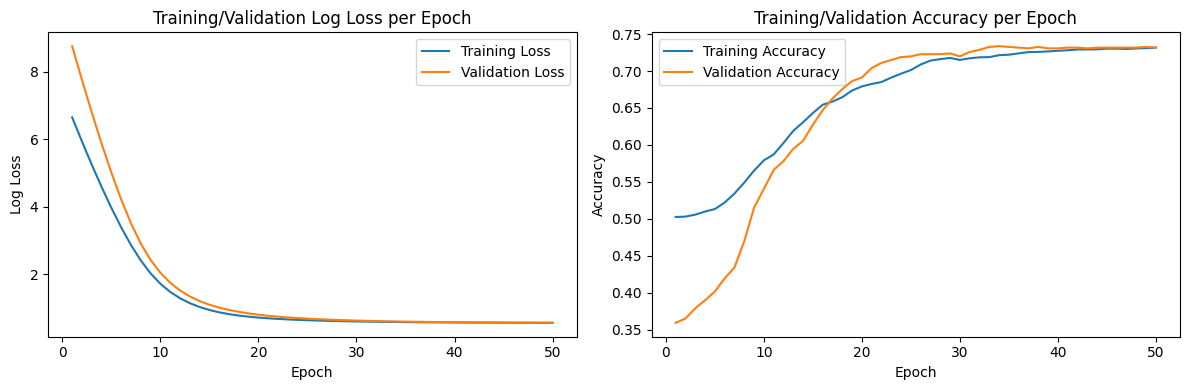

In [9]:
tf.random.set_seed(0)
# build and compile model
model_tf = build_model(X_train_bal.shape[1], 0.001)

# fit the model
train = model_tf.fit(X_train_bal, y_train_bal, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=False)

fig, axes = plt.subplots(1,2, figsize=(12,4))
# generate plot for loss by epoch
axes[0].plot(range(1, len(train.history['loss'])+1), train.history['loss'], label='Training Loss')
axes[0].plot(range(1, len(train.history['val_loss'])+1), train.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('Training/Validation Log Loss per Epoch')
axes[0].legend()

# generate plot for accuracy by epoch
axes[1].plot(range(1, len(train.history['loss'])+1), train.history['accuracy'], label='Training Accuracy')
axes[1].plot(range(1, len(train.history['val_loss'])+1), train.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training/Validation Accuracy per Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# evaluate performance
train_loss = train.history['loss'][-1]
val_loss = train.history['val_loss'][-1]
print('Train data final epoch loss:', round(train_loss,3))
print('Validation data final epoch loss:', round(val_loss,3))

y_train_pred = model_tf.predict(X_train_bal).round()

print("Training Classification Report:")
print(classification_report(y_train_bal, y_train_pred))

Train data final epoch loss: 0.551
Validation data final epoch loss: 0.558
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Training Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      2257
           1       0.73      0.73      0.73      2257

    accuracy                           0.73      4514
   macro avg       0.73      0.73      0.73      4514
weighted avg       0.73      0.73      0.73      4514



### Hyperparameter Tuning

In [11]:
# define model tuner
def build_model_tuner(hp):
    # clear session and use random seed
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)

    # define model
    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Dense(
        units=1,
        input_shape=(X_train_bal.shape[1],),
        activation='sigmoid',
        # kernel_regularizer=regularizer,
        kernel_initializer='glorot_uniform',  
        bias_initializer='zeros',))
        
    # set hyperparameter to tune
    lr = hp.Float('learning rate', min_value=0.0001, max_value=1, sampling='log')

    # set Adam as optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    # finalize the graph for training
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
        
    return model

/Users/timothywong/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/timothywong/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/timothywong/anaconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

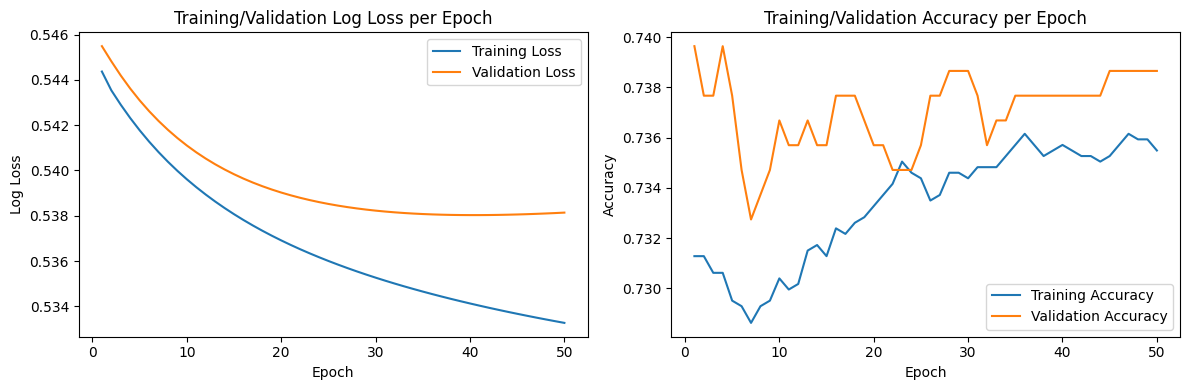

In [12]:
# create tuner
tuner = kt.BayesianOptimization(build_model_tuner, objective=kt.Objective('val_recall', direction='max'), max_trials=20, project_name='dep_tuning', overwrite=True)

# run tuner to search for best learning rate
tuner.search(X_train_bal, y_train_bal, epochs=30, validation_data=(X_val, y_val), verbose=False)

# find the best model
best_model = tuner.get_best_models(num_models=1)[0]

# retrain the best model with more epochs
train_best = best_model.fit(X_train_bal, y_train_bal, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=False)

fig, axes = plt.subplots(1,2, figsize=(12,4))
# generate plot for loss per epoch
axes[0].plot(range(1, len(train_best.history['loss'])+1), train_best.history['loss'], label='Training Loss')
axes[0].plot(range(1, len(train_best.history['val_loss'])+1), train_best.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('Training/Validation Log Loss per Epoch')
axes[0].legend()

# generate plot for accuracy by epoch
axes[1].plot(range(1, len(train_best.history['loss'])+1), train_best.history['accuracy'], label='Training Accuracy')
axes[1].plot(range(1, len(train_best.history['val_loss'])+1), train_best.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training/Validation Accuracy per Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# evaluate val set performance on best model
best_train_loss = train_best.history['loss'][-1]
best_val_loss = train_best.history['val_loss'][-1]
print(f'Train data final epoch loss: {best_train_loss:.3f}')
print(f'Validation data final epoch loss: {best_val_loss:.3f}')

y_val_pred_best_prob = model_tf.predict(X_val).round()
y_val_pred_best = (y_val_pred_best_prob >= 0.5).astype(int)

print("Val Classification Report (best model):")
print(classification_report(y_val, y_val_pred_best, target_names=['No Depression', 'Depression']))

Train data final epoch loss: 0.533
Validation data final epoch loss: 0.538
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Val Classification Report (best model):
               precision    recall  f1-score   support

No Depression       0.88      0.74      0.80       739
   Depression       0.50      0.72      0.59       275

     accuracy                           0.73      1014
    macro avg       0.69      0.73      0.70      1014
 weighted avg       0.78      0.73      0.74      1014



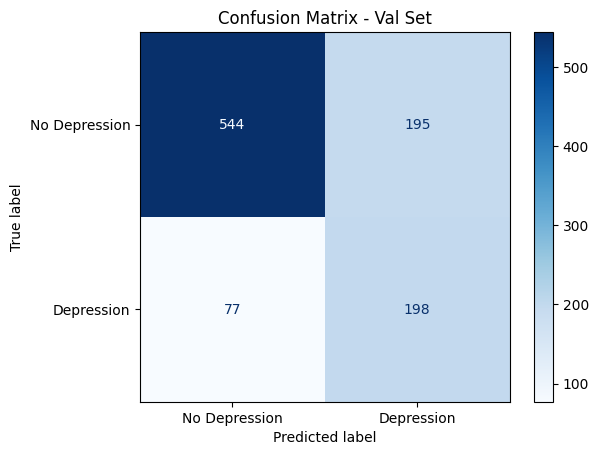

In [15]:
# build confusion matrix for val data (best model)
cm = confusion_matrix(y_val, y_val_pred_best)

disp = ConfusionMatrixDisplay(cm, display_labels=['No Depression', 'Depression'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Val Set')
plt.show()

### Test Evaluation

In [16]:
# evaluate model performance on test data
y_test_pred_prob = model_tf.predict(X_test).round()
y_test_pred = (y_test_pred_prob >= 0.5).astype(int)

# classfication report
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Depression', 'Depression']))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Classification Report:
               precision    recall  f1-score   support

No Depression       0.87      0.70      0.78       776
   Depression       0.40      0.66      0.50       238

     accuracy                           0.69      1014
    macro avg       0.64      0.68      0.64      1014
 weighted avg       0.76      0.69      0.71      1014



In [17]:
# find ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_pred_prob)
print(f'ROC-AUC: {roc_auc:.3f}')

ROC-AUC: 0.680


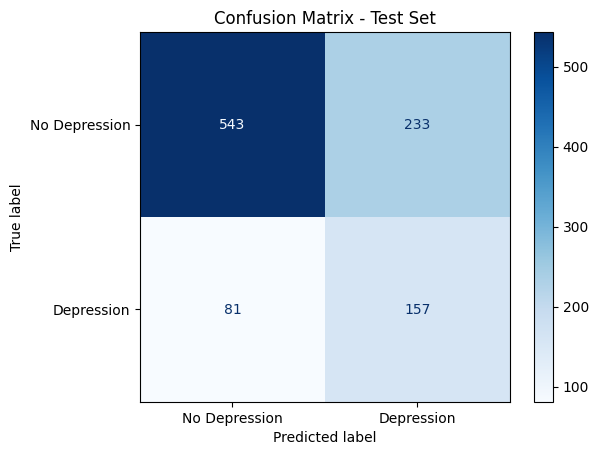

In [18]:
# build confusion matrix for test data
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression'])

disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()

In [ ]:
# save model outputs
joblib.dump(train_best, 'logistic_best_model.pkl')

logistic = joblib.load('logistic_best_model.pkl')